# Задание 1.

Ответьте на вопрос: есть ли связь между жёсткостью воды и средней годовой смертностью?

Постройте точечный график.
Рассчитайте коэффициенты корреляции Пирсона и Спирмена.
Постройте модель линейной регрессии.
Рассчитайте коэффициент детерминации.
Выведите график остатков.

   Unnamed: 0 location        town  mortality  hardness
0           1    South        Bath       1247       105
1           2    North  Birkenhead       1668        17
2           3    South  Birmingham       1466         5
3           4    North   Blackburn       1800        14
4           5    North   Blackpool       1609        18

=== все города ===
Число наблюдений: 61


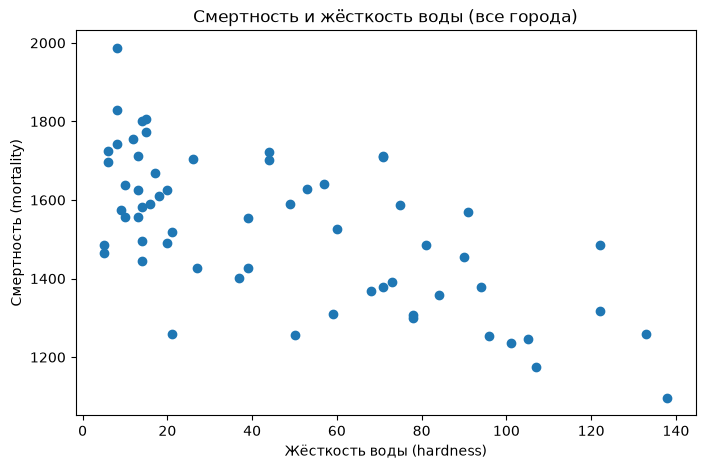

Корреляция Пирсона: -0.6548
Корреляция Спирмена: -0.6317
Уравнение: mortality = 1676.36 + (-3.23) * hardness
Коэффициент детерминации R^2: 0.4288


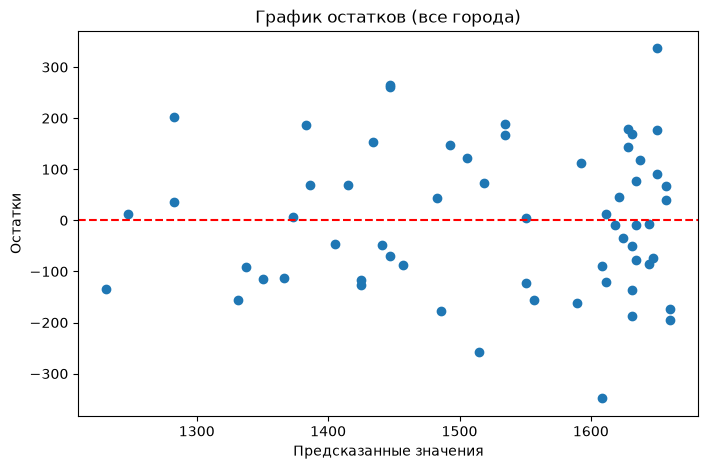

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_water(path):
    return pd.read_csv(path)


def plot_scatter(df, title):
    plt.figure(figsize=(8, 5))
    plt.scatter(df['hardness'], df['mortality'])
    plt.xlabel('Жёсткость воды (hardness)')
    plt.ylabel('Смертность (mortality)')
    plt.title(title)
    plt.show()


def correlation_report(df):
    pearson = df['hardness'].corr(df['mortality'], method='pearson')
    spearman = df['hardness'].rank().corr(df['mortality'].rank(), method='pearson')
    print(f'Корреляция Пирсона: {pearson:.4f}')
    print(f'Корреляция Спирмена: {spearman:.4f}')
    return pearson, spearman


def fit_regression(df):
    x = df['hardness'].to_numpy(dtype=float)
    y = df['mortality'].to_numpy(dtype=float)

    slope, intercept = np.polyfit(x, y, 1)
    y_pred = intercept + slope * x
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    residuals = y - y_pred
    return slope, intercept, r2, y_pred, residuals


def plot_residuals(y_pred, residuals, title):
    plt.figure(figsize=(8, 5))
    plt.scatter(y_pred, residuals)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title(title)
    plt.show()


def analyze(df, name):
    print(f'=== {name} ===')
    print(f'Число наблюдений: {len(df)}')
    plot_scatter(df, f'Смертность и жёсткость воды ({name})')
    pearson, spearman = correlation_report(df)
    slope, intercept, r2, y_pred, residuals = fit_regression(df)
    print(f'Уравнение: mortality = {intercept:.2f} + ({slope:.2f}) * hardness')
    print(f'Коэффициент детерминации R^2: {r2:.4f}')
    plot_residuals(y_pred, residuals, f'График остатков ({name})')
    return pearson, spearman, r2


df = load_water('water.csv')
print(df.head())
print()
pearson_all, spearman_all, r2_all = analyze(df, 'все города')

Вывод по заданию 1:

Между жесткостью воды и смертностью есть обратная связь: чем выше жесткость, тем ниже смертность.

Корреляция Пирсона ≈ −0.65, Спирмена ≈ −0.63 — связь средняя/заметная отрицательная.

R^2 ≈ 0.43: около 43% разброса смертности объясняется жесткостью воды.

На графике остатков нет сильной явной структуры — линейная модель в целом подходит.

# Задание 2.

Ответьте на вопрос: сохраняется ли аналогичная зависимость для северных и южных городов по отдельности?

Разделите данные на 2 группы.
Повторите аналогичные шаги из пункта 1 для каждой группы по отдельности.

=== северные города ===
Число наблюдений: 35


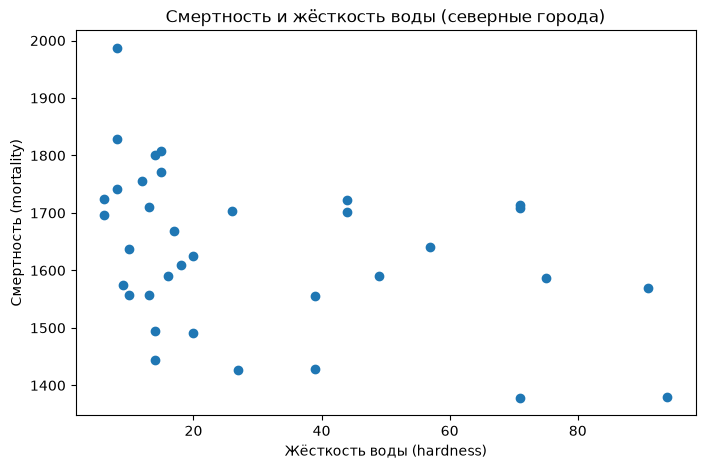

Корреляция Пирсона: -0.3686
Корреляция Спирмена: -0.4042
Уравнение: mortality = 1692.31 + (-1.93) * hardness
Коэффициент детерминации R^2: 0.1359


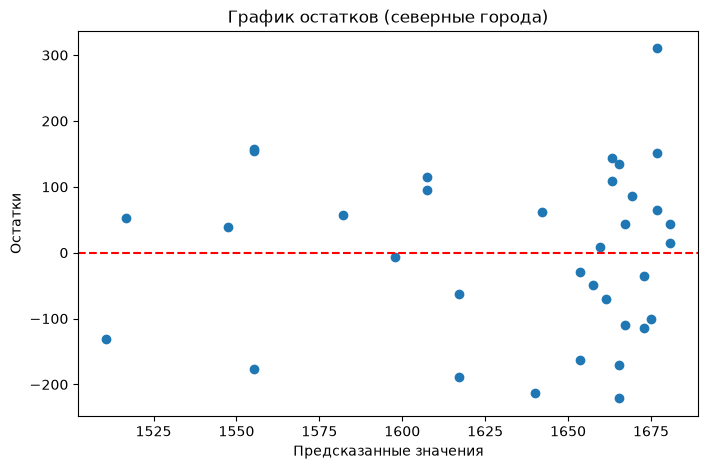


=== южные города ===
Число наблюдений: 26


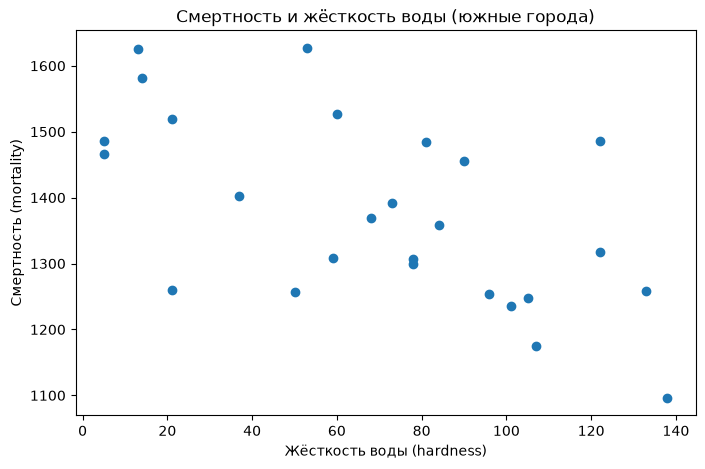

Корреляция Пирсона: -0.6022
Корреляция Спирмена: -0.5957
Уравнение: mortality = 1522.82 + (-2.09) * hardness
Коэффициент детерминации R^2: 0.3626


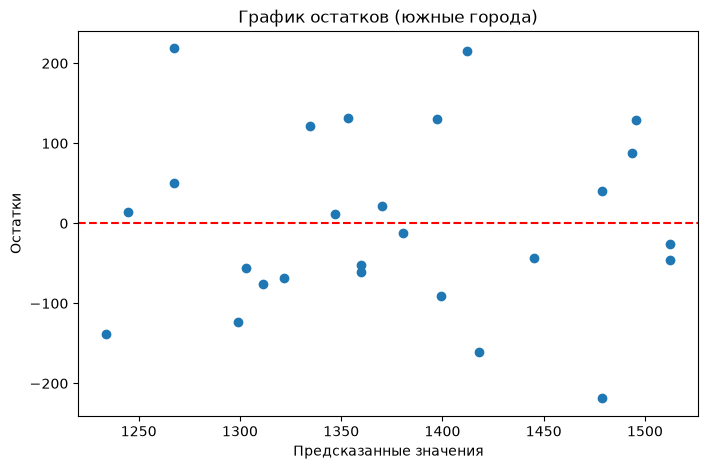

In [2]:
df_north = df[df['location'] == 'North']
df_south = df[df['location'] == 'South']

pearson_n, spearman_n, r2_n = analyze(df_north, 'северные города')
print()
pearson_s, spearman_s, r2_s = analyze(df_south, 'южные города')

Вывод по заданию 2:

Отрицательная зависимость сохраняется и для севера, и для юга, но слабее, чем по всем городам.

Север: корреляция ≈ −0.37, R^2 ≈ 0.14 — связь слабая.

Юг: корреляция ≈ −0.60, R^2 ≈ 0.36 — связь заметнее, ближе к общей.

Часть общей зависимости объясняется различиями севера и юга по жесткости и смертности. 

Итого: аналогичная зависимость сохраняется, но внутри групп (особенно на севере) она слабее.